<a href="https://colab.research.google.com/github/salzirais13/streamlit-intro/blob/main/Churn_Clasification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_excel('/content/WA_Fn-UseC_-Telco-Customer-Churn.xlsx')

# Check for duplicates in the 'customerID' column
duplicates = df[df.duplicated('customerID', keep=False)]

if duplicates.empty:
    print("Tidak ada duplikat di kolom 'customerID'.")
else:
    print("Ada duplikat di kolom 'customerID'. Berikut adalah baris yang memiliki duplikat:")
    display(duplicates)

Tidak ada duplikat di kolom 'customerID'.


In [ ]:
# Encode categorical columns into numerical values
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
df['Partner'] = df['Partner'].map({'No': 0, 'Yes': 1})
df['Dependents'] = df['Dependents'].map({'No': 0, 'Yes': 1})
df['PhoneService'] = df['PhoneService'].map({'No': 0, 'Yes': 1})
df['MultipleLines'] = df['MultipleLines'].map({'No phone service': 0, 'No': 0, 'Yes': 1})
df['OnlineSecurity'] = df['OnlineSecurity'].map({'No': 0, 'Yes': 1, 'No internet service': 0})
df['OnlineBackup'] = df['OnlineBackup'].map({'No': 0, 'Yes': 1, 'No internet service': 0})
df['DeviceProtection'] = df['DeviceProtection'].map({'No': 0, 'Yes': 1, 'No internet service': 0})
df['TechSupport'] = df['TechSupport'].map({'No': 0, 'Yes': 1, 'No internet service': 0})
df['StreamingTV'] = df['StreamingTV'].map({'No': 0, 'Yes': 1, 'No internet service': 0})
df['StreamingMovies'] = df['StreamingMovies'].map({'No': 0, 'Yes': 1, 'No internet service': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'No': 0, 'Yes': 1})
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
df['InternetService'] = df['InternetService'].map({'No': 0, 'DSL': 1, 'Fiber optic': 2})
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df['PaymentMethod'] = df['PaymentMethod'].map({'Electronic check': 0, 'Mailed check': 1, 'Bank transfer (automatic)':2, 'Credit card (automatic)':3})

# Display the first few rows to verify the changes
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,0,1,0,...,0,0,0,0,0,1,0,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,1,1,...,1,0,0,0,1,0,1,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,...,0,0,0,0,0,1,1,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,0,1,1,...,1,1,0,0,1,0,2,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,2,0,...,0,0,0,0,0,1,0,70.70,151.65,1


In [ ]:
# Check the data types of all columns
print("Data types of the DataFrame:")
print(df.dtypes)

Data types of the DataFrame:
customerID           object
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges         object
Churn                 int64
dtype: object


In [ ]:
import numpy as np

# Replace blank spaces with NaN in the 'TotalCharges' column
df['TotalCharges'].replace(" ", np.nan, inplace=True)

# Check for missing values in 'TotalCharges' after replacing blank spaces
print("Jumlah missing value di kolom 'TotalCharges' setelah mengganti spasi kosong:")
print(df['TotalCharges'].isnull().sum())

Jumlah missing value di kolom 'TotalCharges' setelah mengganti spasi kosong:
11


/tmp/ipython-input-3828504319.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].replace(" ", np.nan, inplace=True)
/tmp/ipython-input-3828504319.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['TotalCharges'].replace(" ", np.nan, inplace=True)


In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Display columns with missing values
print("Jumlah missing value di setiap kolom:")
print(missing_values)

Jumlah missing value di setiap kolom:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
# Fill missing values in 'TotalCharges' with the mean of the column
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

# Check for missing values in 'TotalCharges' after imputation
print("Jumlah missing value di kolom 'TotalCharges' setelah diisi dengan rata-rata:")
print(df['TotalCharges'].isnull().sum())

Jumlah missing value di kolom 'TotalCharges' setelah diisi dengan rata-rata:
0


In [ ]:
# Save the preprocessed dataframe to a CSV file
df.to_csv('preprocessed_telco_churn.csv', index=False)

print("Preprocessed data saved to 'preprocessed_telco_churn.csv'")

Preprocessed data saved to 'preprocessed_telco_churn.csv'


In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Display columns with missing values
print("Jumlah missing value di setiap kolom:")
print(missing_values)

Jumlah missing value di setiap kolom:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,0,1,0,...,0,0,0,0,0,1,0,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,1,1,...,1,0,0,0,1,0,1,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,...,0,0,0,0,0,1,1,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,0,1,1,...,1,1,0,0,1,0,2,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,2,0,...,0,0,0,0,0,1,0,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,1,1,1,...,1,1,1,1,1,1,1,84.80,1990.50,0
7039,2234-XADUH,0,0,1,1,72,1,1,2,0,...,1,0,1,1,1,1,3,103.20,7362.90,0
7040,4801-JZAZL,0,0,1,1,11,0,0,1,1,...,0,0,0,0,0,1,0,29.60,346.45,0
7041,8361-LTMKD,1,1,1,0,4,1,1,2,0,...,0,0,0,0,0,1,1,74.40,306.60,1


In [ ]:
# Drop the 'customerID' column
df = df.drop('customerID', axis=1)

# Display the first few rows to verify the change
display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,1,0,29.85,29.85,0
1,1,0,0,0,34,1,0,1,1,0,1,0,0,0,1,0,1,56.95,1889.50,0
2,1,0,0,0,2,1,0,1,1,1,0,0,0,0,0,1,1,53.85,108.15,1
3,1,0,0,0,45,0,0,1,1,0,1,1,0,0,1,0,2,42.30,1840.75,0
4,0,0,0,0,2,1,0,2,0,0,0,0,0,0,0,1,0,70.70,151.65,1


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4930, 19)
Shape of X_test: (2113, 19)
Shape of y_train: (4930,)
Shape of y_test: (2113,)


In [ ]:
# Get the value counts for the 'Churn' column in the training set
churn_train_counts = y_train.value_counts()

# Display the counts
print("Perbandingan jumlah Churn (1) dan Tidak Churn (0) di data latih:")
print(churn_train_counts)

Perbandingan jumlah Churn (1) dan Tidak Churn (0) di data latih:
Churn
0    3635
1    1295
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Display the new class distribution
print("Perbandingan jumlah Churn (1) dan Tidak Churn (0) setelah SMOTE:")
print(y_train_smote.value_counts())

Perbandingan jumlah Churn (1) dan Tidak Churn (0) setelah SMOTE:
Churn
0    3635
1    3635
Name: count, dtype: int64


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the CatBoost model
# CatBoost handles categorical features automatically, but our data is already encoded.
# You can adjust hyperparameters like iterations, learning_rate, depth, etc.
# Set verbose=0 to suppress training output
catboost_model = CatBoostClassifier(random_state=42, verbose=0)

# Train the model using the SMOTE-resampled training data
print("Training CatBoost model...")
catboost_model.fit(X_train_smote, y_train_smote)
print("CatBoost model training complete.")

# Predict on the test data
y_pred_catboost = catboost_model.predict(X_test)

# Evaluate the model
print("\nCatBoost Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_catboost))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_catboost))

Training CatBoost model...
CatBoost model training complete.

CatBoost Model Performance:
Accuracy: 0.779460482725982

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1539
           1       0.58      0.65      0.62       574

    accuracy                           0.78      2113
   macro avg       0.72      0.74      0.73      2113
weighted avg       0.79      0.78      0.78      2113



In [ ]:
# Get feature importances from the trained CatBoost model
feature_importances = catboost_model.get_feature_importance(prettified=True)

# Display the feature importances
print("Feature Importances from CatBoost Model:")
print(feature_importances)

Feature Importances from CatBoost Model:
          Feature Id  Importances
0     MonthlyCharges    19.523155
1           Contract    12.123546
2       TotalCharges    10.643214
3             tenure     8.402872
4    InternetService     6.605520
5      PaymentMethod     5.209551
6       PhoneService     4.321215
7     OnlineSecurity     4.210119
8       OnlineBackup     3.619229
9        TechSupport     3.414138
10       StreamingTV     3.238445
11   StreamingMovies     3.064880
12            gender     2.911026
13  DeviceProtection     2.874060
14           Partner     2.399865
15     MultipleLines     2.249779
16        Dependents     2.237725
17  PaperlessBilling     1.482003
18     SeniorCitizen     1.469659


Visualizing numerical features vs Churn:


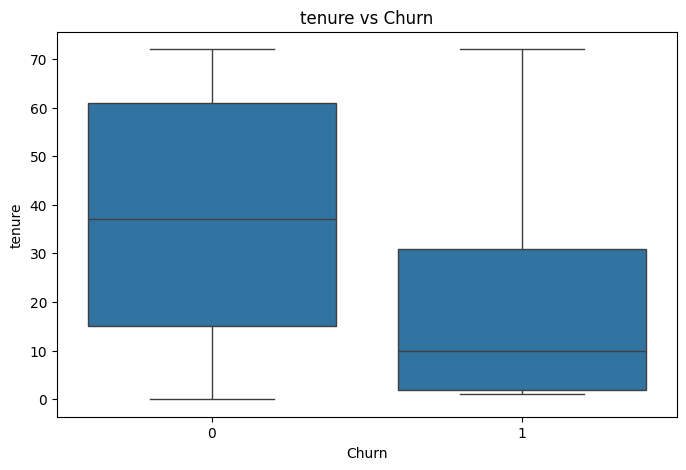

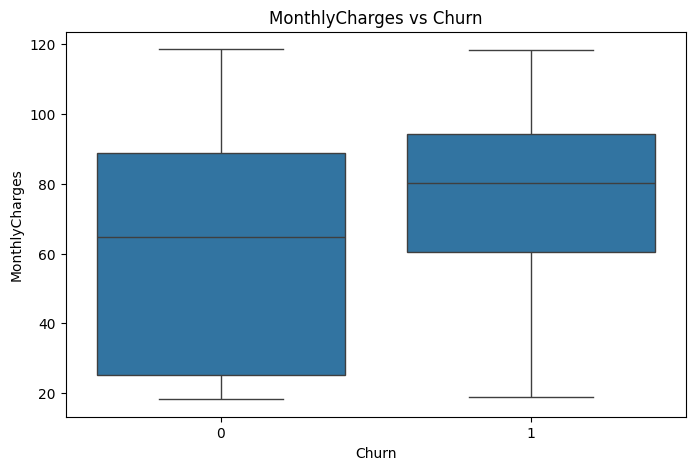

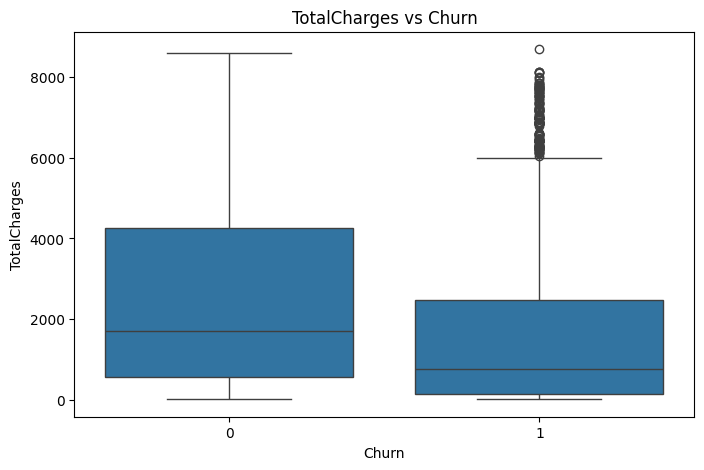


Visualizing categorical features vs Churn:


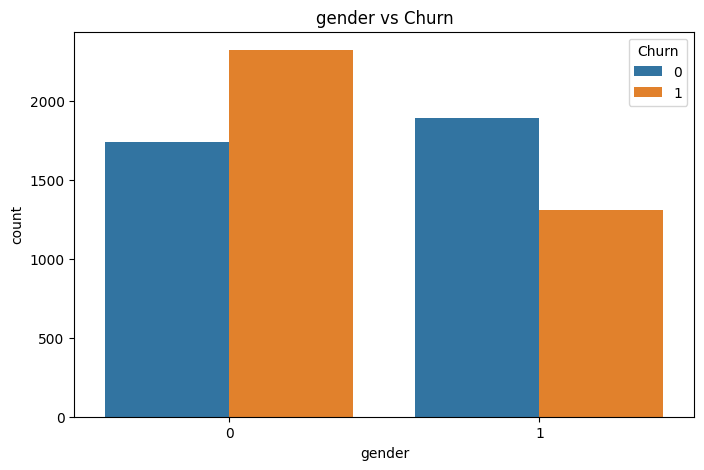

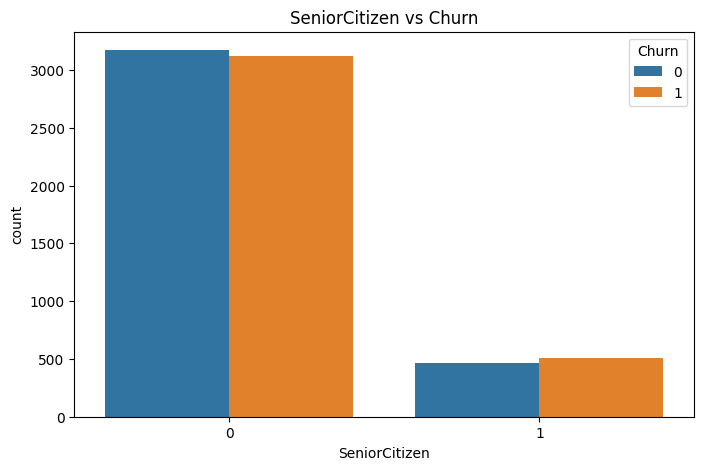

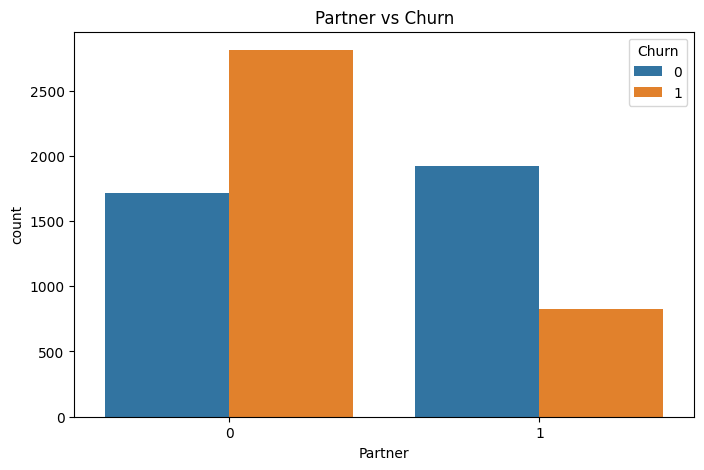

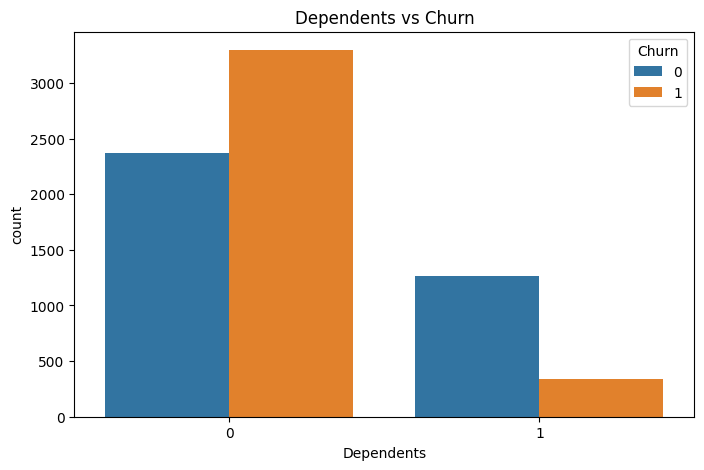

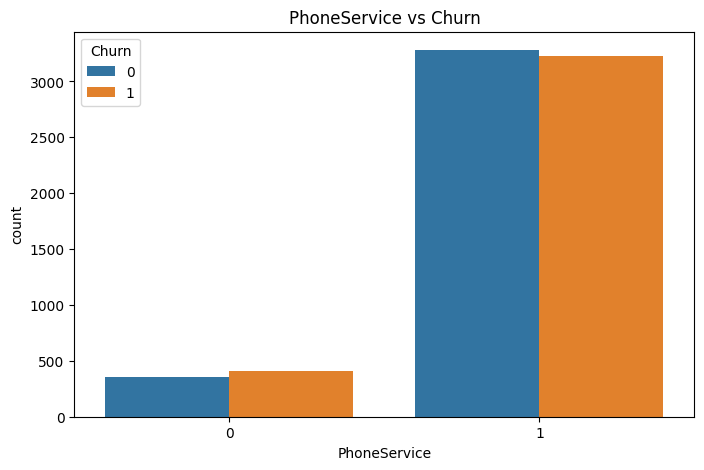

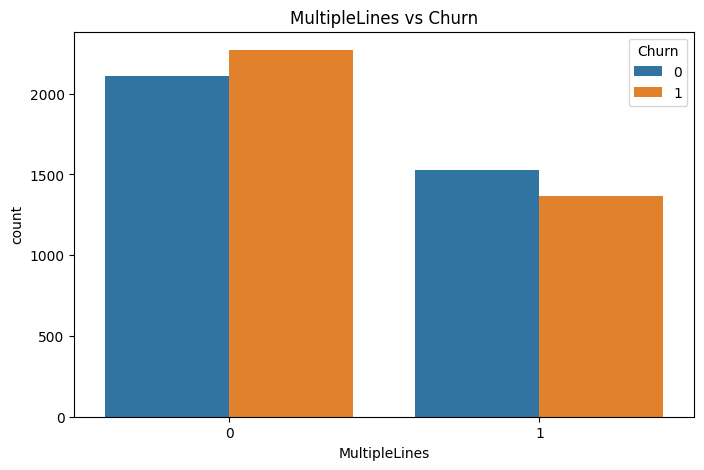

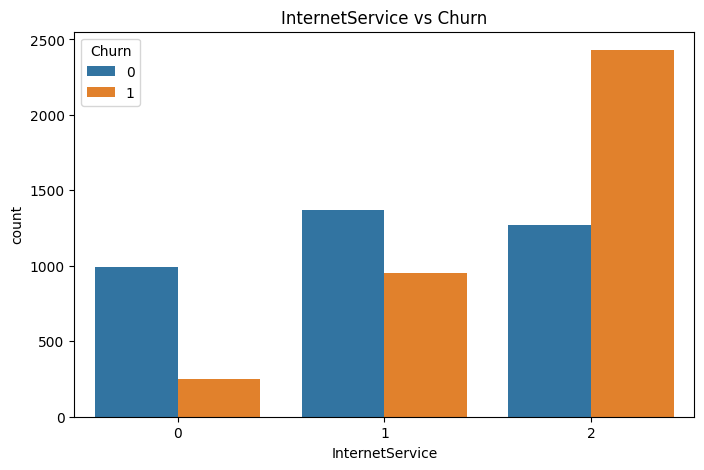

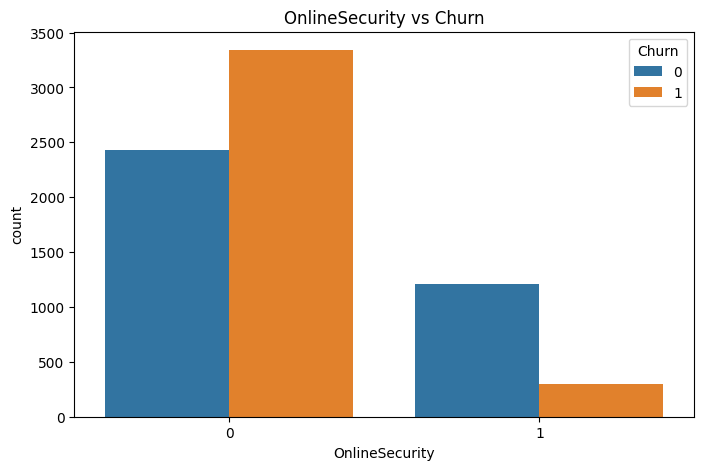

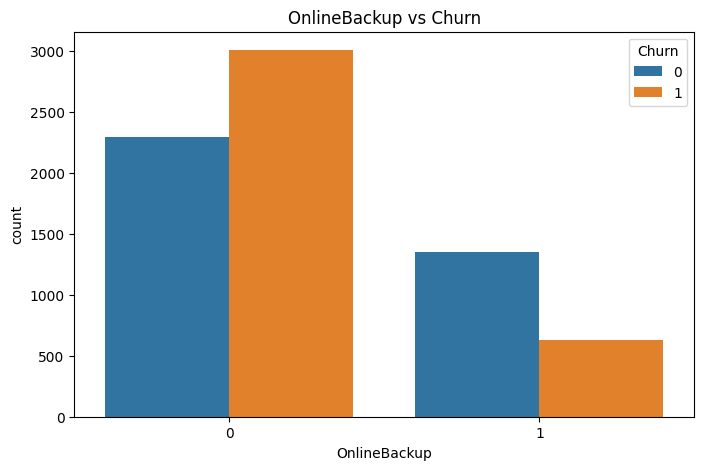

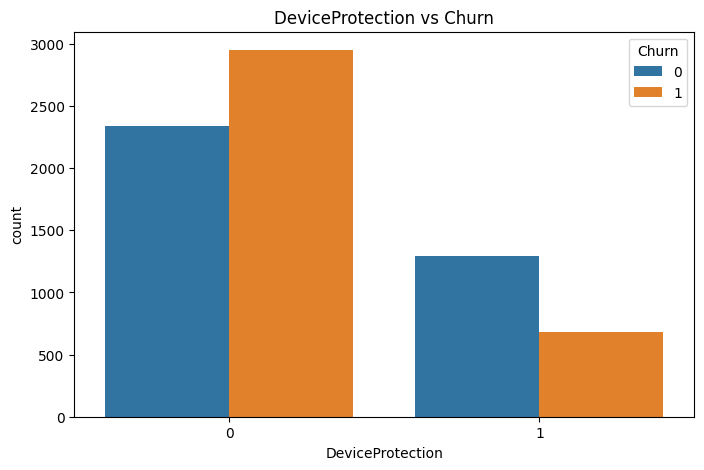

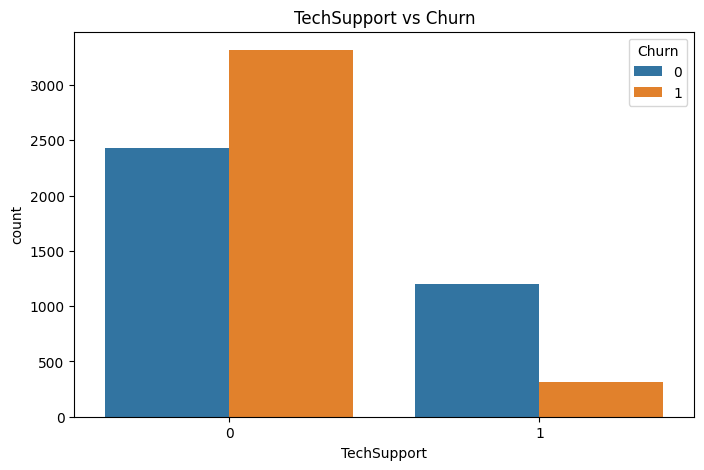

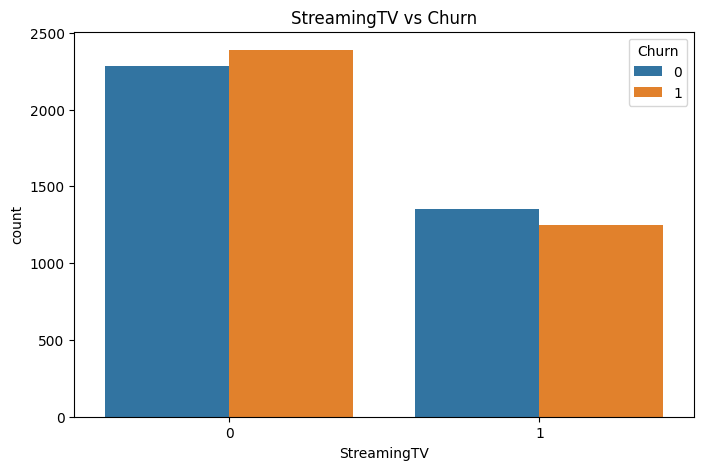

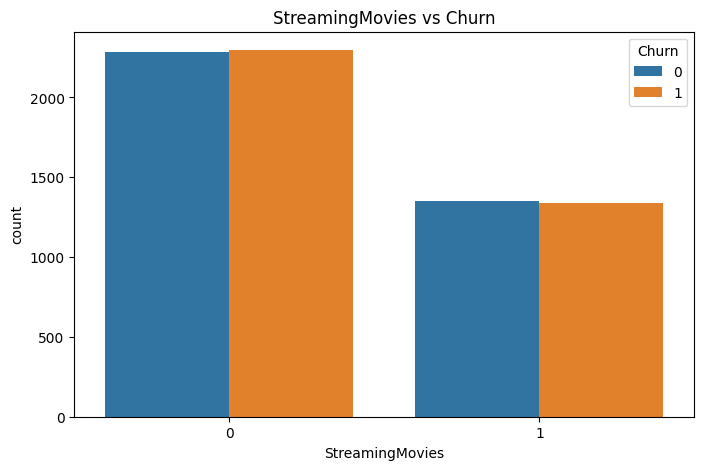

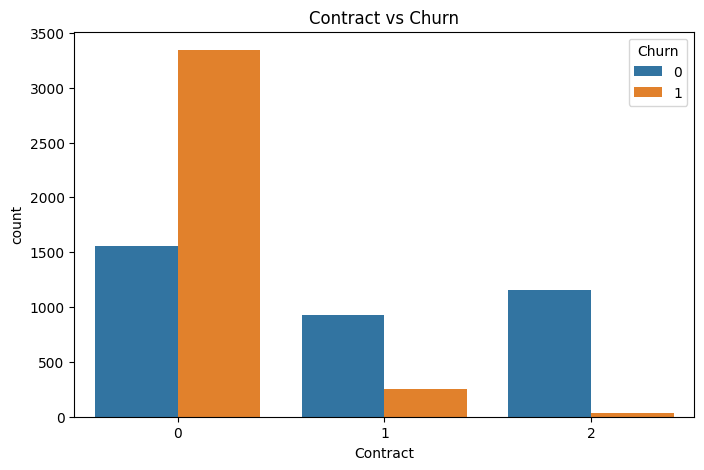

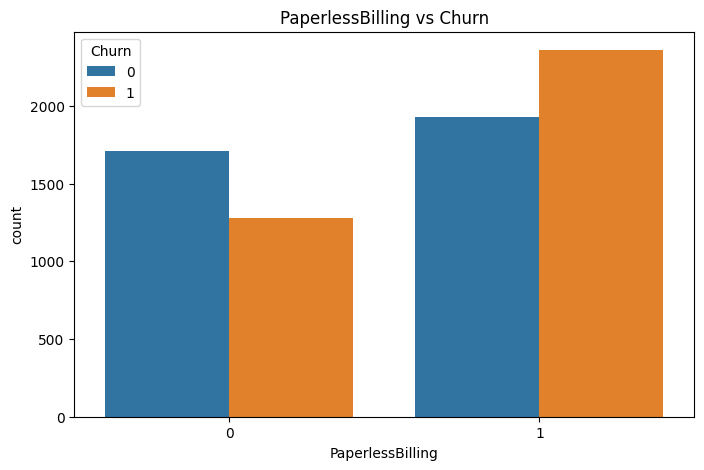

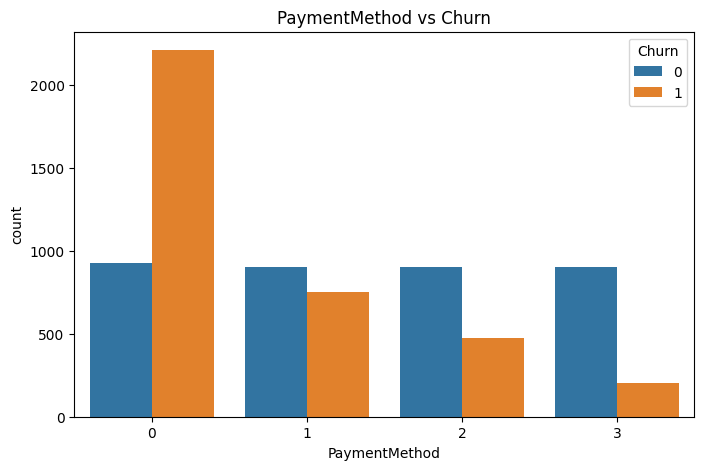

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add the 'Churn' column back to X_train_smote for plotting purposes
X_train_smote_plot = X_train_smote.copy()
X_train_smote_plot['Churn'] = y_train_smote

# Separate features based on their data type (after encoding)
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X_train_smote.columns if col not in numerical_features]

# Plot numerical features vs Churn
print("Visualizing numerical features vs Churn:")
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Churn', y=feature, data=X_train_smote_plot)
    plt.title(f'{feature} vs Churn')
    plt.show()

# Plot categorical features vs Churn
print("\nVisualizing categorical features vs Churn:")
for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=feature, hue='Churn', data=X_train_smote_plot)
    plt.title(f'{feature} vs Churn')
    plt.show()

In [ ]:
# Save the feature_importances dataframe to a CSV file
feature_importances.to_csv('feature_importances.csv', index=False)

print("Feature importances saved to 'feature_importances.csv'")

Feature importances saved to 'feature_importances.csv'


In [ ]:
import pandas as pd

# Load the dataset
df1 = pd.read_excel('/content/WA_Fn-UseC_-Telco-Customer-Churn.xlsx')

In [ ]:
# Predict on the entire preprocessed dataframe (df)
# The catboost_model was trained on the preprocessed data
y_pred_all = catboost_model.predict(df.drop('Churn', axis=1))

# Map the numerical predictions back to 'Yes' and 'No'
reverse_churn_map = {0: 'No', 1: 'Yes'}
predicted_churn_categorical = pd.Series(y_pred_all).map(reverse_churn_map)

# Replace the 'Churn' column in df1 with the predicted churn values
df1['Churn'] = predicted_churn_categorical

# Display the first few rows of df1 to verify the changes
print("DataFrame df1 with predicted Churn values:")
display(df1.head())

# Display the value counts of the predicted Churn column in df1
print("\nValue counts of Predicted Churn in df1:")
print(df1['Churn'].value_counts())

DataFrame df1 with predicted Churn values:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Value counts of Predicted Churn in df1:
Churn
No     4993
Yes    2050
Name: count, dtype: int64


In [ ]:
# Save the df1 dataframe to a CSV file
df1.to_csv('df1_with_predictions.csv', index=False)

print("DataFrame df1 saved to 'df1_with_predictions.csv'")

DataFrame df1 saved to 'df1_with_predictions.csv'


In [ ]:
import pickle
pickle.dump(catboost_model, open('catboost_churn_model.pkl', 'wb'))
